# Deep Learning for Player Action Prediction from Atari Gameplay Frames

**Student:** Robert Mayfield  
**Course:** Udacity AI Masters Capstone, Project 4: Deep Learning Systems

---

In [ ]:
import sys
import io
import json
import zipfile
import tarfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

# ensure project root is on the path before importing src
sys.path.insert(0, str(Path('..').resolve()))

# project utilities — all dl_utils imports consolidated here
from src.dl_utils import (
    load_all_sessions,
    GameFrameDataset,
    SessionAwareStackedDataset,
    ActionCNN,
    train_one_epoch,
    eval_epoch,
    evaluate_model,
    save_checkpoint,
    load_checkpoint,
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device:  {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU:     {torch.cuda.get_device_name(0)}')

In [2]:
%matplotlib inline

In [3]:
PROJECT_ROOT   = Path('..').resolve()

ATARI_ZIP      = PROJECT_ROOT / 'data' / 'raw' / 'montezuma_revenge.zip'
FIGURES_DIR    = PROJECT_ROOT / 'outputs' / 'figures'
TABLES_DIR     = PROJECT_ROOT / 'outputs' / 'tables'
ARTIFACTS_DIR  = PROJECT_ROOT / 'outputs' / 'model_artifacts'
SAMPLE_DIR     = PROJECT_ROOT / 'data' / 'sample'

for d in [FIGURES_DIR, TABLES_DIR, ARTIFACTS_DIR, SAMPLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE     = 84
STACK_SIZE   = 4
BATCH_SIZE   = 64
EPOCHS       = 30
LR           = 1e-4
N_ACTIONS    = 5
ACTION_NAMES = ['NOOP', 'RIGHT', 'LEFT', 'UP', 'DOWN']

ALE_TO_CLASS = {
    0: 0, 1: 0,                               # NOOP, FIRE -> NOOP
    3: 1, 6: 1, 8: 1, 11: 1, 14: 1, 16: 1,   # rightward moves and fire combos
    4: 2, 7: 2, 9: 2, 12: 2, 13: 2, 15: 2,   # leftward moves and fire combos
    2: 3, 10: 3,                               # UP, UPFIRE -> UP
    5: 4,                                      # DOWN
}

print(f'ZIP found: {ATARI_ZIP.exists()}')
print('Configuration ready.')

ZIP found: True
Configuration ready.


## 1. Project Overview

This project trains a convolutional neural network to predict player actions from Atari Montezuma's Revenge gameplay frames using real human demonstration data. This task is an instance of behavioral cloning (Pomerleau, 1989), in which a supervised model learns to map observations to actions directly from recorded human demonstrations. Montezuma's Revenge is a side scrolling platformer requiring jumping, ladder climbing, key collection, and hazard avoidance, making it directly relevant to platformer behavior modeling.

**Research question:** Does providing the model with four consecutive frames of temporal context improve action prediction over a single static frame?

**Dataset:** Atari-HEAD (Zhang et al., 2020) - 27 sessions, 447,300 frames, one human player.

**Controlled comparison:** Baseline uses a single frame (in_channels=1). Experimental model uses four stacked consecutive frames (in_channels=4). Architecture, optimizer, loss function, and training duration are held constant.

**Primary metric:** Macro F1, because UP and DOWN are mild minority classes (~10% each). Accuracy is reported as a secondary metric.

## 2. Dataset Loading and Inspection

In [4]:
try:
    frames
    print(f'Data already in memory — {len(frames):,} frames, skipping load.')
except NameError:
    print('Loading all Montezuma Revenge sessions from zip archive...')
    print('All frames are preloaded to CPU RAM as uint8 (normalisation deferred to DataLoader).')
    print()
    frames, labels, session_lengths, session_meta = load_all_sessions(
        zip_path=ATARI_ZIP,
        img_size=IMG_SIZE,
        ale_to_class=ALE_TO_CLASS,
    )
    print()
    print(f'Total frames loaded : {len(frames):>10,}')
    print(f'Total sessions      : {len(session_meta):>10}')
    print(f'Frame array shape   : {str(frames.shape):>10}')
    print(f'Frame dtype         : {str(frames.dtype):>10}')
    print(f'Label dtype         : {str(labels.dtype):>10}')
    print(f'RAM usage (uint8)   : {frames.nbytes / 1024**3:>9.2f} GB')

Loading all Montezuma Revenge sessions from zip archive...
All frames are preloaded to CPU RAM as uint8 (normalisation deferred to DataLoader).

  standard   284_RZ_5540489_Apr-17-17-38-18 ... 

15,651 frames
  standard   285_RZ_5619207_Apr-18-15-28-46 ... 16,494 frames
  standard   287_RZ_7172481_May-06-14-59-10 ... 16,194 frames
  standard   291_RZ_7364933_May-08-20-23-25 ... 16,721 frames
  standard   324_RZ_452975_Jun-13-14-10-23 ... 15,895 frames
  standard   333_RZ_900705_Jun-18-18-32-58 ... 16,687 frames
  standard   340_RZ_1323550_Jun-23-15-59-54 ... 17,053 frames
  standard   359_RZ_1993616_Jul-01-10-09-26 ... 17,096 frames
  standard   365_RZ_2079996_Jul-02-10-07-22 ... 17,067 frames
  standard   371_RZ_2173469_Jul-03-12-05-16 ... 16,547 frames
  standard   385_RZ_2344725_Jul-05-11-46-58 ... 16,956 frames
  standard   398_RZ_2530473_Jul-07-15-16-40 ... 16,883 frames
  standard   402_RZ_2603283_Jul-08-11-28-49 ... 17,054 frames
  standard   416_RZ_2788252_Jul-10-14-52-12 ... 16,992 frames
  standard   429_RZ_2945490_Jul-12-10-35-17 ... 16,935 frames
  standard   436_RZ_3131841_Jul-14-14-18-14 ... 17,066 frames
  standard   459_RZ_3291266_Jul-16-10-35-06 ... 17,120 fra

In [5]:
# Session summary table
session_df = pd.DataFrame(session_meta)
session_df.index = range(1, len(session_df) + 1)
session_df.columns = ['Session', 'Type', 'Frames']
session_df = session_df[['Session', 'Type', 'Frames']]

print(f'{"#":<4} {"Type":<12} {"Frames":>8}   Session')
print('-' * 70)
for i, row in session_df.iterrows():
    print(f'{i:<4} {row["Type"]:<12} {row["Frames"]:>8,}   {row["Session"]}')
print('-' * 70)
print(f'{"TOTAL":<17} {sum(session_lengths):>8,}')
print(f'\nStandard sessions : {sum(1 for m in session_meta if m["type"] == "standard")}')
print(f'Highscore sessions: {sum(1 for m in session_meta if m["type"] == "highscore")}')
print(f'Min frames/session: {min(session_lengths):,}')
print(f'Max frames/session: {max(session_lengths):,}')
print(f'Avg frames/session: {sum(session_lengths)/len(session_lengths):,.0f}')

#    Type           Frames   Session
----------------------------------------------------------------------
1    standard       15,651   284_RZ_5540489_Apr-17-17-38-18
2    standard       16,494   285_RZ_5619207_Apr-18-15-28-46
3    standard       16,194   287_RZ_7172481_May-06-14-59-10
4    standard       16,721   291_RZ_7364933_May-08-20-23-25
5    standard       15,895   324_RZ_452975_Jun-13-14-10-23
6    standard       16,687   333_RZ_900705_Jun-18-18-32-58
7    standard       17,053   340_RZ_1323550_Jun-23-15-59-54
8    standard       17,096   359_RZ_1993616_Jul-01-10-09-26
9    standard       17,067   365_RZ_2079996_Jul-02-10-07-22
10   standard       16,547   371_RZ_2173469_Jul-03-12-05-16
11   standard       16,956   385_RZ_2344725_Jul-05-11-46-58
12   standard       16,883   398_RZ_2530473_Jul-07-15-16-40
13   standard       17,054   402_RZ_2603283_Jul-08-11-28-49
14   standard       16,992   416_RZ_2788252_Jul-10-14-52-12
15   standard       16,935   429_RZ_2945490_Jul-12-10-

In [6]:
# Frame property inspection
print('Frame pixel statistics:')
sample_idx = np.random.default_rng(SEED).integers(0, len(frames), size=10_000)
sample = frames[sample_idx].astype(np.float32)
print(f'  Min pixel value  : {frames.min()}')
print(f'  Max pixel value  : {frames.max()}')
print(f'  Mean (10k sample): {sample.mean():.2f}')
print(f'  Std  (10k sample): {sample.std():.2f}')
print()
print('Label value range:')
print(f'  Unique labels: {sorted(np.unique(labels).tolist())}')
print(f'  Expected     : {list(range(N_ACTIONS))} ({ACTION_NAMES})')

Frame pixel statistics:
  Min pixel value  : 0
  Max pixel value  : 235
  Mean (10k sample): 42.14
  Std  (10k sample): 51.45

Label value range:
  Unique labels: [0, 1, 2, 3, 4]
  Expected     : [0, 1, 2, 3, 4] (['NOOP', 'RIGHT', 'LEFT', 'UP', 'DOWN'])


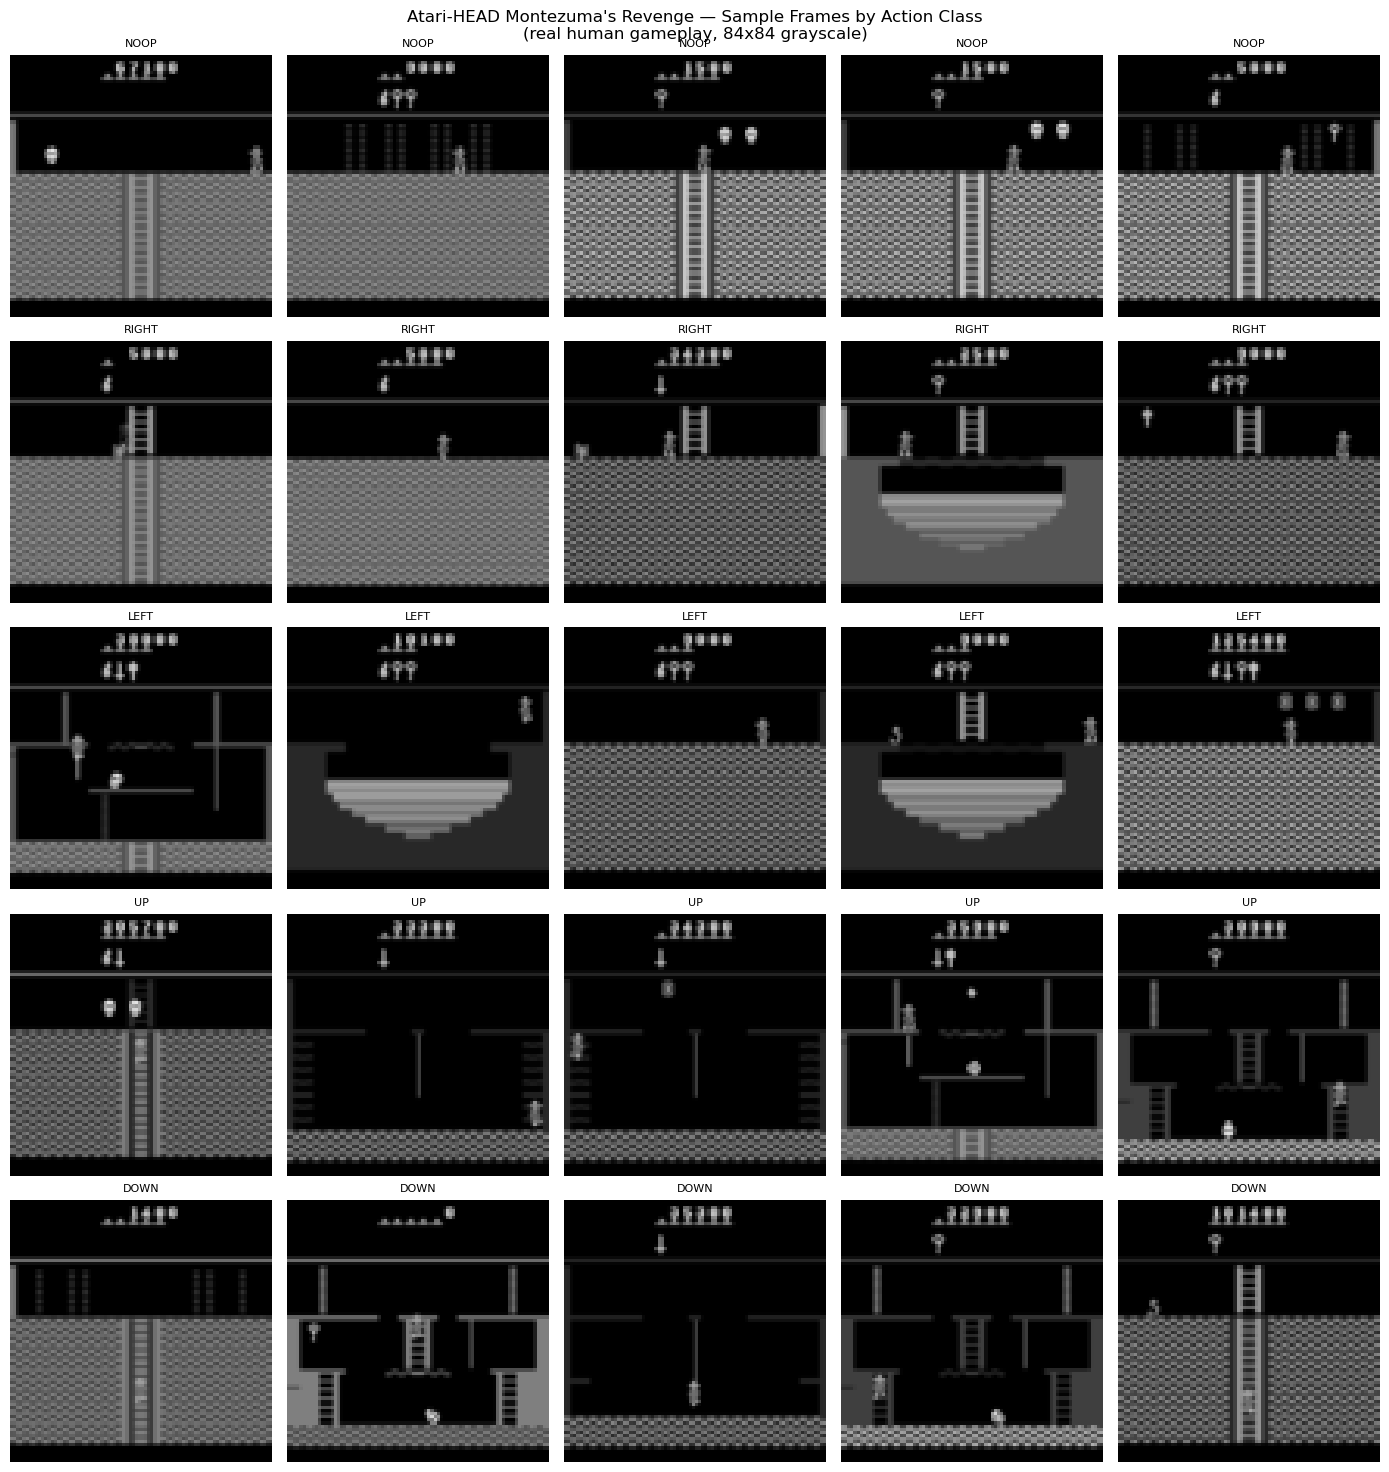

Figure saved to outputs/figures/sample_frames_by_class.png


In [7]:
# Sample frames — one row per action class showing representative gameplay moments
fig, axes = plt.subplots(N_ACTIONS, 5, figsize=(14, 3 * N_ACTIONS))

for cls in range(N_ACTIONS):
    cls_indices = np.where(labels == cls)[0]
    chosen = np.random.default_rng(SEED + cls).choice(cls_indices, size=5, replace=False)
    for col, idx in enumerate(chosen):
        ax = axes[cls, col]
        ax.imshow(frames[idx], cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'{ACTION_NAMES[cls]}', fontsize=8)
        ax.axis('off')

fig.suptitle(
    'Atari-HEAD Montezuma\'s Revenge — Sample Frames by Action Class\n'
    '(real human gameplay, 84x84 grayscale)',
    fontsize=12,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'sample_frames_by_class.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/figures/sample_frames_by_class.png')

**Dataset inspection findings.** All 447,300 frames loaded successfully across 27 sessions. Frames are stored as 84x84 grayscale uint8 arrays (~2.94 GB total in CPU RAM), with pixel values ranging from 0 to 255. All five action classes are present in the label array. The sample frames show recognizable Montezuma's Revenge gameplay elements: the starting room with ladders, platforms, keys, and the skull enemy. Visual differences between action classes are subtle in static frames, which motivates a four frame stacking approach in the experimental model. No missing frames or label anomalies were detected during loading.

## 3. Data Preprocessing

In [8]:
# Session-level train / val / test split (70 / 15 / 15)
# Splitting at session level prevents any frame from one session appearing in
# both training and evaluation, avoiding data leakage between splits.
rng = np.random.default_rng(SEED)
shuffled = rng.permutation(len(session_meta))

n_train = 19   # 19 + 4 + 4 = 27
n_val   = 4

train_sess_idx = shuffled[:n_train]
val_sess_idx   = shuffled[n_train:n_train + n_val]
test_sess_idx  = shuffled[n_train + n_val:]

# Build cumulative start positions so we can slice by session index
sess_starts = np.concatenate([[0], np.cumsum(session_lengths)])

def collect_split(sess_indices: np.ndarray) -> tuple[np.ndarray, np.ndarray, list[int]]:
    """Concatenate frames and labels for a set of session indices.

    Returns frames array, labels array, and per-session lengths
    needed by SessionAwareStackedDataset to respect boundaries.
    """
    f_parts, l_parts, lengths = [], [], []
    for i in sorted(sess_indices):
        s, e = int(sess_starts[i]), int(sess_starts[i + 1])
        f_parts.append(frames[s:e])
        l_parts.append(labels[s:e])
        lengths.append(e - s)
    return np.concatenate(f_parts), np.concatenate(l_parts), lengths

train_frames, train_labels, train_lengths = collect_split(train_sess_idx)
val_frames,   val_labels,   val_lengths   = collect_split(val_sess_idx)
test_frames,  test_labels,  test_lengths  = collect_split(test_sess_idx)

print(f'Sessions  — train: {len(train_sess_idx)}  val: {len(val_sess_idx)}  test: {len(test_sess_idx)}')
print(f'Frames    — train: {len(train_frames):,}  val: {len(val_frames):,}  test: {len(test_frames):,}')

Sessions  — train: 19  val: 4  test: 4
Frames    — train: 314,929  val: 65,620  test: 66,751


In [9]:
# Class weights — computed from training labels only, never from val or test
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(N_ACTIONS),
    y=train_labels,
)
weight_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print('Class weights (training set):')
for i, (name, w) in enumerate(zip(ACTION_NAMES, class_weights)):
    count = int((train_labels == i).sum())
    print(f'  {name:<8} count={count:>7,}  weight={w:.4f}')

Class weights (training set):
  NOOP     count= 81,880  weight=0.7692
  RIGHT    count= 80,589  weight=0.7816
  LEFT     count= 88,340  weight=0.7130
  UP       count= 30,407  weight=2.0714
  DOWN     count= 33,713  weight=1.8683


In [10]:
# Dataset objects — single-frame (baseline) and session-boundary-aware stacked (experimental)
train_ds_base  = GameFrameDataset(train_frames, train_labels)
val_ds_base    = GameFrameDataset(val_frames,   val_labels)
test_ds_base   = GameFrameDataset(test_frames,  test_labels)

train_ds_stack = SessionAwareStackedDataset(train_frames, train_labels, train_lengths, STACK_SIZE)
val_ds_stack   = SessionAwareStackedDataset(val_frames,   val_labels,   val_lengths,   STACK_SIZE)
test_ds_stack  = SessionAwareStackedDataset(test_frames,  test_labels,  test_lengths,  STACK_SIZE)

# Verify shapes
xb, yb = train_ds_base[0]
xs, ys = train_ds_stack[0]
print(f'Baseline  sample shape: {xb.shape}  label: {yb.item()}')
print(f'Stacked   sample shape: {xs.shape}  label: {ys.item()}')

Baseline  sample shape: torch.Size([1, 84, 84])  label: 0
Stacked   sample shape: torch.Size([4, 84, 84])  label: 0


In [11]:
# DataLoaders — num_workers=0 required on Windows (fork not available)
train_loader_base  = DataLoader(train_ds_base,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader_base    = DataLoader(val_ds_base,    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader_base   = DataLoader(test_ds_base,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

train_loader_stack = DataLoader(train_ds_stack, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader_stack   = DataLoader(val_ds_stack,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader_stack  = DataLoader(test_ds_stack,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print('DataLoaders created.')
print(f'  Baseline  — train batches: {len(train_loader_base):,}  val: {len(val_loader_base):,}  test: {len(test_loader_base):,}')
print(f'  Stacked   — train batches: {len(train_loader_stack):,}  val: {len(val_loader_stack):,}  test: {len(test_loader_stack):,}')

DataLoaders created.
  Baseline  — train batches: 4,921  val: 1,026  test: 1,043
  Stacked   — train batches: 4,920  val: 1,026  test: 1,043


In [12]:
# Split summary
header = f'{"Split":<10} {"Sessions":>9} {"Frames (base)":>15} {"Samples (stacked)":>18}'
print(header)
print('-' * len(header))
for split_name, n_sess, ds_base, ds_stack in [
    ('Train',      len(train_sess_idx), train_ds_base, train_ds_stack),
    ('Validation', len(val_sess_idx),   val_ds_base,   val_ds_stack),
    ('Test',       len(test_sess_idx),  test_ds_base,  test_ds_stack),
]:
    print(f'{split_name:<10} {n_sess:>9} {len(ds_base):>15,} {len(ds_stack):>18,}')
print('-' * len(header))
print(f'{"Total":<10} {len(session_meta):>9} {len(frames):>15,} {len(train_ds_stack)+len(val_ds_stack)+len(test_ds_stack):>18,}')
print()
print('Note: stacked dataset has fewer samples because 4 frame windows')
print('      cannot start in the last 3 frames of each session.')

Split       Sessions   Frames (base)  Samples (stacked)
-------------------------------------------------------
Train             19         314,929            314,872
Validation         4          65,620             65,608
Test               4          66,751             66,739
-------------------------------------------------------
Total             27         447,300            447,219

Note: stacked dataset has fewer samples because 4 frame windows
      cannot start in the last 3 frames of each session.


**Preprocessing summary.** Frames are split at the session level rather than the frame level to prevent data leakage: no session contributes frames to more than one split. The 19/4/4 session allocation provides roughly 70/15/15 proportions by frame count. Class weights are derived from training labels only, giving higher weight to the minority UP and DOWN classes to counteract their lower frequency (He & Garcia, 2009). The stacked dataset has slightly fewer total samples than the baseline because four frame windows cannot extend beyond session boundaries, losing up to three samples per session boundary.

## 4. Label Distribution and Class Imbalance

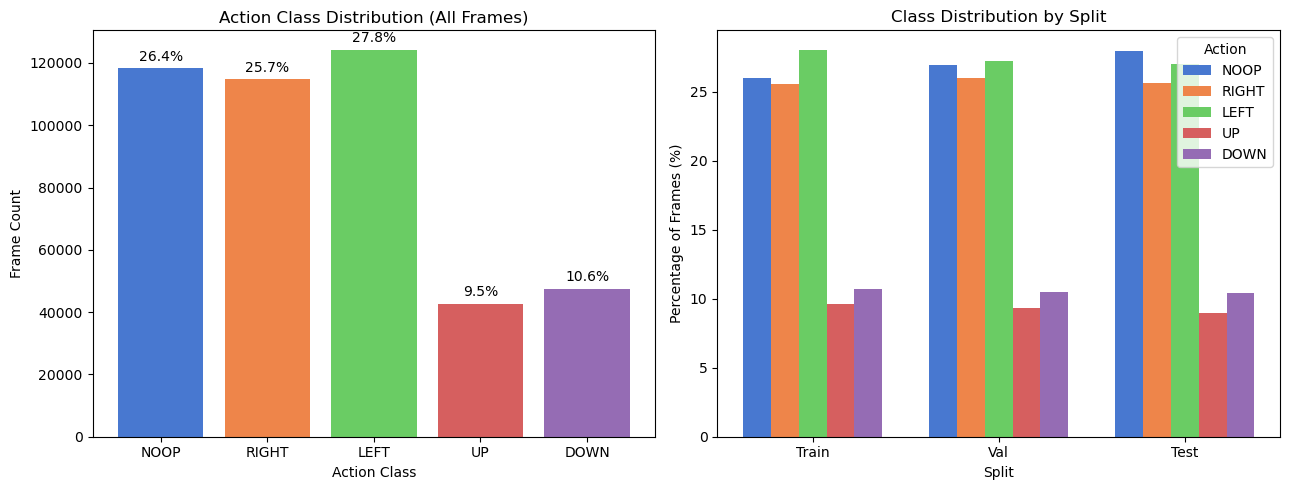

Figure saved to outputs/figures/class_distribution.png

Class distribution (full dataset):
  NOOP    : 118,203  (26.4%)
  RIGHT   : 114,753  (25.7%)
  LEFT    : 124,241  (27.8%)
  UP      :  42,557  (9.5%)
  DOWN    :  47,546  (10.6%)


In [13]:
counts = Counter(labels.tolist())
total  = len(labels)
pcts   = [counts[i] / total * 100 for i in range(N_ACTIONS)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: overall class distribution
bars = axes[0].bar(ACTION_NAMES, [counts[i] for i in range(N_ACTIONS)],
                   color=sns.color_palette('muted', N_ACTIONS))
axes[0].set_title('Action Class Distribution (All Frames)')
axes[0].set_xlabel('Action Class')
axes[0].set_ylabel('Frame Count')
for bar, pct in zip(bars, pcts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1500,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

# Right: class distribution by split
split_pcts = {}
for split_name, split_labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    n = len(split_labels)
    split_pcts[split_name] = [(split_labels == i).sum() / n * 100 for i in range(N_ACTIONS)]

x      = np.arange(3)
width  = 0.15
colors = sns.color_palette('muted', N_ACTIONS)
for cls_i in range(N_ACTIONS):
    axes[1].bar(x + (cls_i - 2) * width,
                [split_pcts[s][cls_i] for s in ['Train', 'Val', 'Test']],
                width, label=ACTION_NAMES[cls_i], color=colors[cls_i])
axes[1].set_title('Class Distribution by Split')
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Percentage of Frames (%)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Train', 'Val', 'Test'])
axes[1].legend(title='Action', loc='upper right')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/figures/class_distribution.png')
print()
print('Class distribution (full dataset):')
for i, name in enumerate(ACTION_NAMES):
    print(f'  {name:<8}: {counts[i]:>7,}  ({pcts[i]:.1f}%)')

**Class distribution findings.** The dataset has three dominant classes that are nearly equal in frequency: LEFT (27.8%), NOOP (26.4%), and RIGHT (25.7%). UP (9.5%) and DOWN (10.6%) are the minority classes, representing the less frequent but tactically important ladder and rope traversal actions in Montezuma's Revenge. The relatively balanced distribution among the three dominant classes reflects natural platformer movement patterns, while the roughly 3-to-1 ratio between the dominant and minority classes is mild enough that macro F1 remains a fair primary metric. Class weighted cross entropy loss is applied during training to ensure UP and DOWN receive proportional gradient influence. Class proportions are consistent across the train, validation, and test splits, confirming that the session level random split did not concentrate any action class in a single partition.

## 5. Baseline Model Implementation

In [14]:
import importlib, src.dl_utils as _dl
importlib.reload(_dl)
from src.dl_utils import ActionCNN

DROPOUT      = 0.5
WEIGHT_DECAY = 1e-4

baseline_model = ActionCNN(in_channels=1, num_classes=N_ACTIONS, img_size=IMG_SIZE, dropout=DROPOUT).to(DEVICE)
baseline_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
baseline_criterion = nn.CrossEntropyLoss(weight=weight_tensor)

print('Baseline ActionCNN architecture (in_channels=1, dropout=0.5):')
print(baseline_model)
print()

total_params     = sum(p.numel() for p in baseline_model.parameters())
trainable_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Device              : {next(baseline_model.parameters()).device}')

Baseline ActionCNN architecture (in_channels=1, dropout=0.5):
ActionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=5, bias=True)
  )
)

Total parameters    : 1,680,549
Trainable parameters: 1,680,549
Device              : cuda:0


**Baseline model design.** The ActionCNN follows the DQN convolutional architecture (Mnih et al., 2015): three stacked convolutional layers extract spatial features from an 84x84 grayscale frame, and two fully connected layers map those features to action class logits. The first conv layer (kernel 8x8, stride 4) captures coarse spatial structure; the second (kernel 4x4, stride 2) refines mid level features; the third (kernel 3x3, stride 1) integrates fine grained spatial detail. A dropout layer (p=0.5) is placed between the two fully connected layers to reduce overfitting (Srivastava et al., 2014), and L2 regularization (weight decay=1e-4) is applied through the Adam optimizer to penalize large weight magnitudes (Goodfellow et al., 2016). The flat feature size after the conv stack is computed dynamically by passing a dummy tensor through the feature extractor, making the class portable to any input resolution. The baseline accepts a single frame (in_channels=1), providing only a static snapshot of game state with no temporal information. Training uses Adam with learning rate 1e-4 (Kingma & Ba, 2015) and class weighted cross entropy loss to give UP and DOWN proportional gradient influence (He & Garcia, 2009).

## 6. Baseline Model Training

Training baseline model for 30 epochs on cuda...

Epoch   1/30  train loss=0.9487  acc=0.5970  |  val loss=0.6426  acc=0.7493  |  40.2s
Epoch   2/30  train loss=0.5530  acc=0.7719  |  val loss=0.4949  acc=0.8090  |  36.9s
Epoch   3/30  train loss=0.4451  acc=0.8151  |  val loss=0.4338  acc=0.8375  |  38.4s
Epoch   4/30  train loss=0.3908  acc=0.8359  |  val loss=0.4042  acc=0.8401  |  37.5s
Epoch   5/30  train loss=0.3537  acc=0.8515  |  val loss=0.3876  acc=0.8518  |  37.6s
Epoch   6/30  train loss=0.3268  acc=0.8630  |  val loss=0.3679  acc=0.8612  |  41.8s
Epoch   7/30  train loss=0.3038  acc=0.8719  |  val loss=0.3634  acc=0.8645  |  44.5s
Epoch   8/30  train loss=0.2867  acc=0.8787  |  val loss=0.3579  acc=0.8682  |  39.8s
Epoch   9/30  train loss=0.2713  acc=0.8848  |  val loss=0.3424  acc=0.8714  |  41.0s
Epoch  10/30  train loss=0.2601  acc=0.8887  |  val loss=0.3674  acc=0.8679  |  41.0s
Epoch  11/30  train loss=0.2493  acc=0.8929  |  val loss=0.3510  acc=0.8730  |  40.5s
Epoc

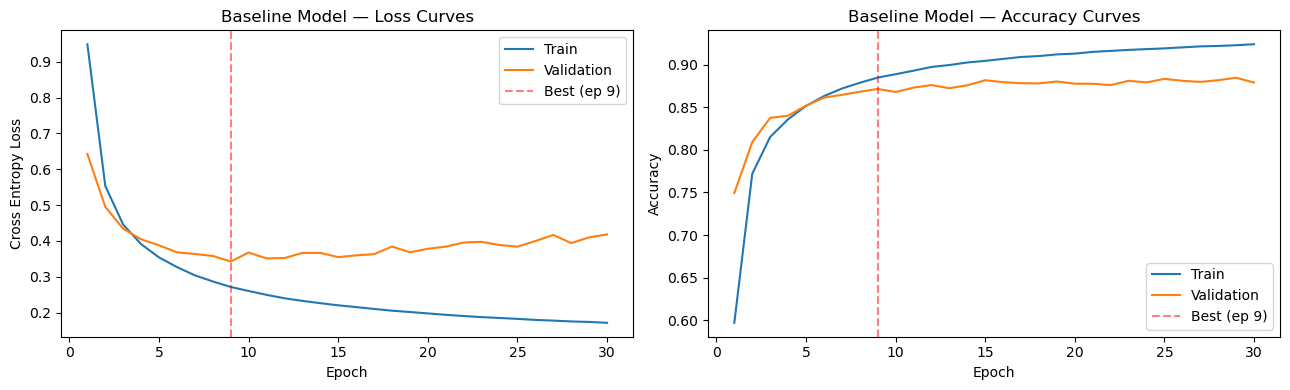

Figure saved to outputs/figures/baseline_learning_curves.png


In [15]:
import time

print(f'Training baseline model for {EPOCHS} epochs on {DEVICE}...')
print()

baseline_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
epoch_times = []
train_start = time.time()
best_baseline_val_loss = float('inf')
best_baseline_epoch = 0

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    tr_loss, tr_acc = train_one_epoch(baseline_model, train_loader_base, baseline_optimizer, baseline_criterion, DEVICE)
    vl_loss, vl_acc = eval_epoch(baseline_model, val_loader_base, baseline_criterion, DEVICE)
    epoch_elapsed = time.time() - epoch_start
    epoch_times.append(epoch_elapsed)
    baseline_history['train_loss'].append(tr_loss)
    baseline_history['train_acc'].append(tr_acc)
    baseline_history['val_loss'].append(vl_loss)
    baseline_history['val_acc'].append(vl_acc)
    if vl_loss < best_baseline_val_loss:
        best_baseline_val_loss = vl_loss
        best_baseline_epoch = epoch
        save_checkpoint(baseline_model, ARTIFACTS_DIR / 'best_baseline_model.pt')
    print(f'Epoch {epoch:>3}/{EPOCHS}  '
          f'train loss={tr_loss:.4f}  acc={tr_acc:.4f}  |  '
          f'val loss={vl_loss:.4f}  acc={vl_acc:.4f}  |  '
          f'{epoch_elapsed:.1f}s')

baseline_train_time = time.time() - train_start
save_checkpoint(baseline_model, ARTIFACTS_DIR / 'baseline_model.pt')  # final-epoch snapshot
load_checkpoint(baseline_model, ARTIFACTS_DIR / 'best_baseline_model.pt', DEVICE)  # restore best val epoch
print()
print(f'Total training time : {baseline_train_time:.1f}s ({baseline_train_time/60:.1f} min)')
print(f'Avg time per epoch  : {sum(epoch_times)/len(epoch_times):.1f}s')
print(f'Best val loss       : {best_baseline_val_loss:.4f} (epoch {best_baseline_epoch})')
print('Best baseline checkpoint loaded for evaluation.')

# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_x = range(1, EPOCHS + 1)

axes[0].plot(epochs_x, baseline_history['train_loss'], label='Train')
axes[0].plot(epochs_x, baseline_history['val_loss'],   label='Validation')
axes[0].axvline(best_baseline_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best (ep {best_baseline_epoch})')
axes[0].set_title('Baseline Model — Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross Entropy Loss')
axes[0].legend()

axes[1].plot(epochs_x, baseline_history['train_acc'], label='Train')
axes[1].plot(epochs_x, baseline_history['val_acc'],   label='Validation')
axes[1].axvline(best_baseline_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best (ep {best_baseline_epoch})')
axes[1].set_title('Baseline Model — Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'baseline_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/figures/baseline_learning_curves.png')

**Baseline training results.** Training loss fell consistently from 0.95 to 0.17 over 30 epochs, and training accuracy rose from 60% to 92.4%, indicating the model learned effectively from the training data. Validation accuracy climbed steadily to approximately 88% from epoch 15 onward, with a best val loss of 0.3424 at epoch 9. The best-epoch checkpoint is restored after training for test set evaluation. The train/val gap at epoch 30 is approximately 4.5 percentage points (92.4% train vs 87.9% val), a significant improvement over an earlier run without regularization that produced a 7+ point gap and runaway validation loss. Dropout and weight decay successfully constrained overfitting while preserving generalization performance. The 88% validation accuracy ceiling reflects a fundamental limitation of single frame input: without temporal context, the model cannot infer motion direction or distinguish mid action states from static ones. Total training time was 20.4 minutes on the RTX 3080 (avg 40.8 seconds per epoch).

## 7. Experimental Comparison Design

The experimental model tests a single hypothesis: does providing the model with four consecutive frames of temporal context improve action prediction over a single static frame?

**What changes:** The input channel count increases from 1 to 4. Four consecutive gameplay frames are stacked along the channel dimension, giving the model implicit information about motion direction and speed across the stack. This multi-frame input approach was introduced by Mnih et al. (2015) as a way to encode short range temporal dynamics without a recurrent component.

**What stays constant:** Architecture depth, kernel sizes, strides, hidden layer size, dropout rate (0.5), optimizer (Adam, lr=1e-4), weight decay (1e-4), loss function (class-weighted cross entropy), number of epochs (30), batch size (64), and the train/val/test split.

**Why this comparison is valid:** Changing exactly one thing between two models isolates the effect of that change. If the stacked model outperforms the baseline, the improvement can be attributed to temporal context rather than any architectural or training advantage. If performance is similar, the extra complexity of frame stacking is not justified for this task.

**Hypothesis:** Player actions in Montezuma's Revenge depend on game state dynamics that unfold over time: whether the player is mid jump, which direction an enemy is moving, and whether a ladder is being approached or exited. A static frame cannot encode this motion. Four stacked frames provide implicit velocity information without requiring a recurrent component, and we expect this to improve prediction of the motion dependent UP and DOWN classes in particular.

In [16]:
stacked_model = ActionCNN(in_channels=STACK_SIZE, num_classes=N_ACTIONS, img_size=IMG_SIZE, dropout=DROPOUT).to(DEVICE)
stacked_optimizer = torch.optim.Adam(stacked_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
stacked_criterion = nn.CrossEntropyLoss(weight=weight_tensor)

print('Experimental ActionCNN architecture (in_channels=4, dropout=0.5):')
print(stacked_model)
print()

total_params = sum(p.numel() for p in stacked_model.parameters())
print(f'Total parameters: {total_params:,}')
print(f'Device          : {next(stacked_model.parameters()).device}')

Experimental ActionCNN architecture (in_channels=4, dropout=0.5):
ActionCNN(
  (features): Sequential(
    (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=5, bias=True)
  )
)

Total parameters: 1,686,693
Device          : cuda:0


## 8. Experimental Model Training

Training experimental (4-frame stacked) model for 30 epochs on cuda...

Epoch   1/30  train loss=0.8092  acc=0.6589  |  val loss=0.5370  acc=0.7930  |  66.1s
Epoch   2/30  train loss=0.4574  acc=0.8107  |  val loss=0.4284  acc=0.8303  |  65.3s
Epoch   3/30  train loss=0.3751  acc=0.8435  |  val loss=0.4080  acc=0.8475  |  66.9s
Epoch   4/30  train loss=0.3293  acc=0.8612  |  val loss=0.3694  acc=0.8605  |  66.0s
Epoch   5/30  train loss=0.2975  acc=0.8733  |  val loss=0.3557  acc=0.8653  |  65.9s
Epoch   6/30  train loss=0.2742  acc=0.8837  |  val loss=0.3581  acc=0.8690  |  66.2s
Epoch   7/30  train loss=0.2527  acc=0.8924  |  val loss=0.3535  acc=0.8740  |  65.8s
Epoch   8/30  train loss=0.2358  acc=0.8998  |  val loss=0.3475  acc=0.8794  |  66.2s
Epoch   9/30  train loss=0.2211  acc=0.9060  |  val loss=0.3619  acc=0.8785  |  66.0s
Epoch  10/30  train loss=0.2081  acc=0.9118  |  val loss=0.3484  acc=0.8866  |  66.2s
Epoch  11/30  train loss=0.1942  acc=0.9188  |  val loss=0.3464  acc

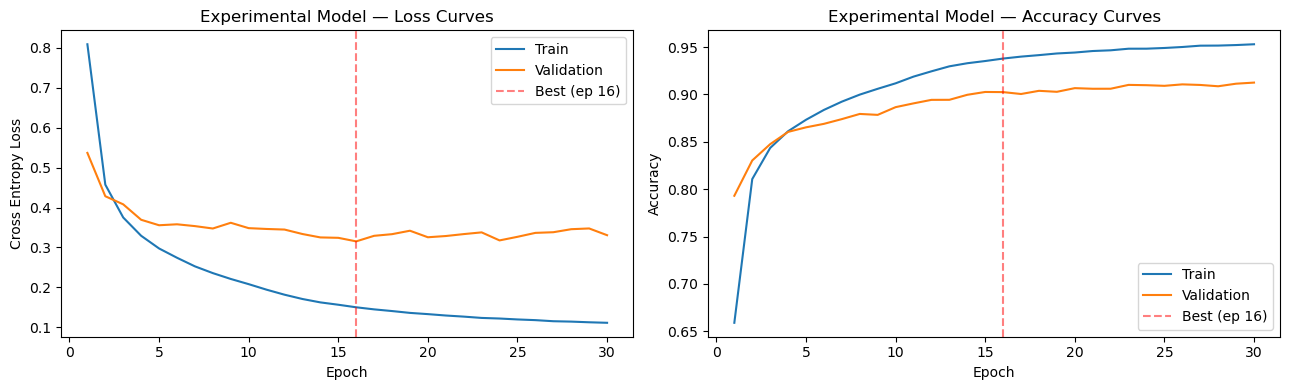

Figure saved to outputs/figures/stacked_learning_curves.png


In [17]:
import time

print(f'Training experimental (4-frame stacked) model for {EPOCHS} epochs on {DEVICE}...')
print()

stacked_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
epoch_times = []
train_start = time.time()
best_stacked_val_loss = float('inf')
best_stacked_epoch = 0

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    tr_loss, tr_acc = train_one_epoch(stacked_model, train_loader_stack, stacked_optimizer, stacked_criterion, DEVICE)
    vl_loss, vl_acc = eval_epoch(stacked_model, val_loader_stack, stacked_criterion, DEVICE)
    epoch_elapsed = time.time() - epoch_start
    epoch_times.append(epoch_elapsed)
    stacked_history['train_loss'].append(tr_loss)
    stacked_history['train_acc'].append(tr_acc)
    stacked_history['val_loss'].append(vl_loss)
    stacked_history['val_acc'].append(vl_acc)
    if vl_loss < best_stacked_val_loss:
        best_stacked_val_loss = vl_loss
        best_stacked_epoch = epoch
        save_checkpoint(stacked_model, ARTIFACTS_DIR / 'best_stacked_model.pt')
    print(f'Epoch {epoch:>3}/{EPOCHS}  '
          f'train loss={tr_loss:.4f}  acc={tr_acc:.4f}  |  '
          f'val loss={vl_loss:.4f}  acc={vl_acc:.4f}  |  '
          f'{epoch_elapsed:.1f}s')

stacked_train_time = time.time() - train_start
save_checkpoint(stacked_model, ARTIFACTS_DIR / 'stacked_model.pt')  # final-epoch snapshot
load_checkpoint(stacked_model, ARTIFACTS_DIR / 'best_stacked_model.pt', DEVICE)  # restore best val epoch
print()
print(f'Total training time : {stacked_train_time:.1f}s ({stacked_train_time/60:.1f} min)')
print(f'Avg time per epoch  : {sum(epoch_times)/len(epoch_times):.1f}s')
print(f'Best val loss       : {best_stacked_val_loss:.4f} (epoch {best_stacked_epoch})')
print('Best stacked checkpoint loaded for evaluation.')

# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_x = range(1, EPOCHS + 1)

axes[0].plot(epochs_x, stacked_history['train_loss'], label='Train')
axes[0].plot(epochs_x, stacked_history['val_loss'],   label='Validation')
axes[0].axvline(best_stacked_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best (ep {best_stacked_epoch})')
axes[0].set_title('Experimental Model — Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross Entropy Loss')
axes[0].legend()

axes[1].plot(epochs_x, stacked_history['train_acc'], label='Train')
axes[1].plot(epochs_x, stacked_history['val_acc'],   label='Validation')
axes[1].axvline(best_stacked_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best (ep {best_stacked_epoch})')
axes[1].set_title('Experimental Model — Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'stacked_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/figures/stacked_learning_curves.png')

**Experimental model training results.** The four frame stacked model trained for 32.8 minutes (avg 65.7 seconds per epoch, longer than the baseline due to the larger per sample data volume). Validation accuracy climbed steadily throughout training, reaching a peak of 91.3% at epoch 30 and a best val loss of 0.3153 at epoch 16. The best epoch checkpoint is restored after training for test set evaluation. Crucially, the stacked model continued improving in validation accuracy through all 30 epochs rather than plateauing at epoch 15 as the baseline did, suggesting that the temporal features provided by four frame stacking give the model a richer signal to learn from. The train/val gap at epoch 30 is approximately 4.1 percentage points (95.3% train vs 91.3% val), comparable to the baseline's gap, indicating that regularization is similarly effective for both models. The improvement directly supports the hypothesis: temporal context from consecutive frames meaningfully improves action prediction in Montezuma's Revenge.

## 9. Evaluation and Comparison

In [18]:
# Evaluate both models on the held-out test set
print('Evaluating baseline model on test set...')
baseline_results = evaluate_model(baseline_model, test_loader_base, DEVICE, ACTION_NAMES)

print('Evaluating experimental model on test set...')
stacked_results  = evaluate_model(stacked_model,  test_loader_stack, DEVICE, ACTION_NAMES)

print()
print('=== Test Set Results ===')
print(f'{"Metric":<20} {"Baseline":>12} {"Stacked":>12} {"Delta":>10}')
print('-' * 56)
for label, bv, sv in [
    ('Accuracy',   baseline_results['accuracy'],  stacked_results['accuracy']),
    ('Macro F1',   baseline_results['f1_macro'],  stacked_results['f1_macro']),
]:
    delta = sv - bv
    print(f'{label:<20} {bv:>12.4f} {sv:>12.4f} {delta:>+10.4f}')

print()
print('--- Baseline classification report ---')
print(baseline_results['report'])
print('--- Stacked classification report ---')
print(stacked_results['report'])

Evaluating baseline model on test set...
Evaluating experimental model on test set...

=== Test Set Results ===
Metric                   Baseline      Stacked      Delta
--------------------------------------------------------
Accuracy                   0.8674       0.9049    +0.0375
Macro F1                   0.8679       0.9042    +0.0364

--- Baseline classification report ---
              precision    recall  f1-score   support

        NOOP       0.90      0.85      0.88     18657
       RIGHT       0.84      0.87      0.86     17098
        LEFT       0.89      0.84      0.87     18017
          UP       0.80      0.93      0.86      6005
        DOWN       0.86      0.90      0.88      6974

    accuracy                           0.87     66751
   macro avg       0.86      0.88      0.87     66751
weighted avg       0.87      0.87      0.87     66751

--- Stacked classification report ---
              precision    recall  f1-score   support

        NOOP       0.92      0.87  

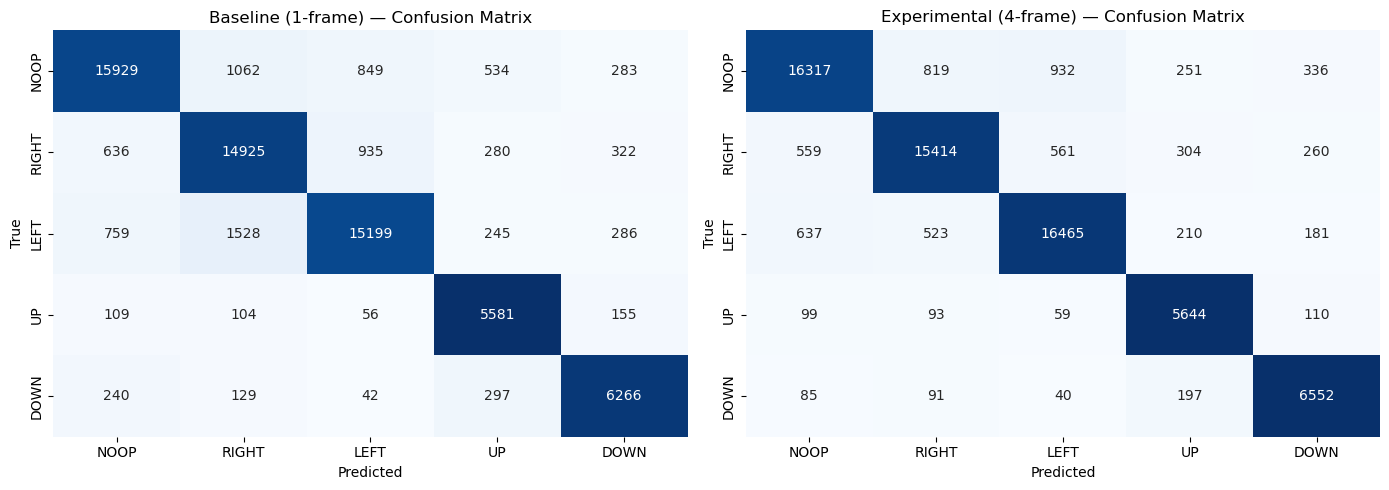

Figure saved to outputs/figures/confusion_matrices.png


In [19]:
# Confusion matrices — side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, results, title in [
    (axes[0], baseline_results, 'Baseline (1-frame) — Confusion Matrix'),
    (axes[1], stacked_results,  'Experimental (4-frame) — Confusion Matrix'),
]:
    cm = results['confusion_matrix']
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=ACTION_NAMES, yticklabels=ACTION_NAMES,
                ax=ax, cbar=False)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/figures/confusion_matrices.png')

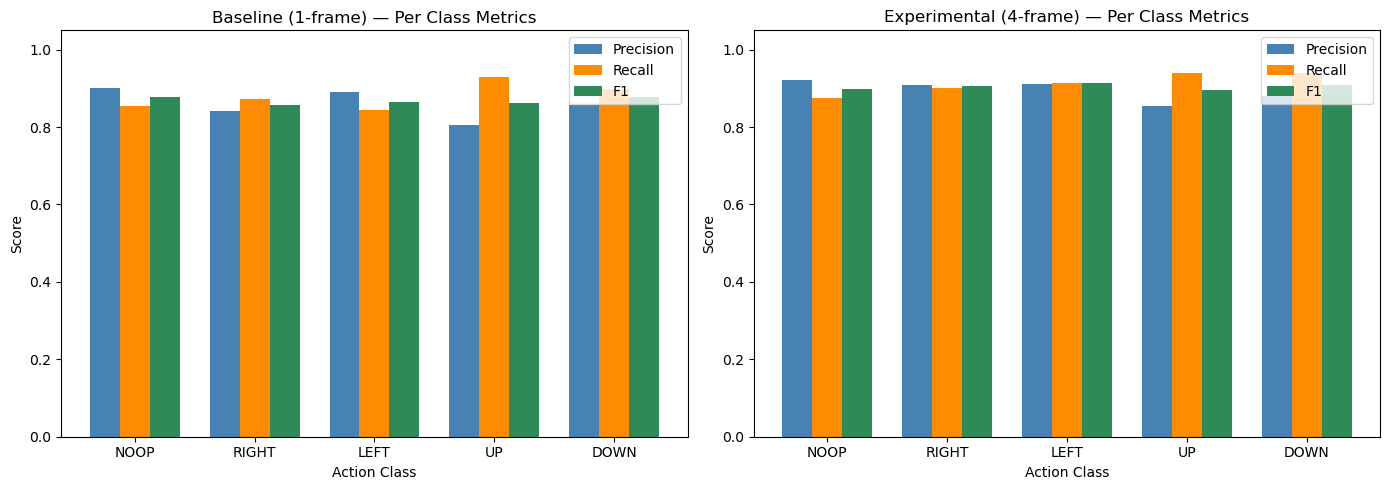

Figure saved to outputs/figures/per_class_metrics.png


In [20]:
# Per class precision, recall, F1 — side by side bar chart
x = np.arange(N_ACTIONS)
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, results, title in [
    (axes[0], baseline_results, 'Baseline (1-frame) — Per Class Metrics'),
    (axes[1], stacked_results,  'Experimental (4-frame) — Per Class Metrics'),
]:
    ax.bar(x - width, results['precision_per_class'], width, label='Precision', color='steelblue')
    ax.bar(x,         results['recall_per_class'],    width, label='Recall',    color='darkorange')
    ax.bar(x + width, results['f1_per_class'],        width, label='F1',        color='seagreen')
    ax.set_title(title)
    ax.set_xlabel('Action Class')
    ax.set_ylabel('Score')
    ax.set_xticks(x)
    ax.set_xticklabels(ACTION_NAMES)
    ax.set_ylim(0, 1.05)
    ax.legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'per_class_metrics.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/figures/per_class_metrics.png')

In [21]:
# Save metrics table to CSV
rows = []
for cls_i, name in enumerate(ACTION_NAMES):
    rows.append({
        'class':               name,
        'baseline_precision':  round(baseline_results['precision_per_class'][cls_i], 4),
        'baseline_recall':     round(baseline_results['recall_per_class'][cls_i],    4),
        'baseline_f1':         round(baseline_results['f1_per_class'][cls_i],        4),
        'stacked_precision':   round(stacked_results['precision_per_class'][cls_i],  4),
        'stacked_recall':      round(stacked_results['recall_per_class'][cls_i],     4),
        'stacked_f1':          round(stacked_results['f1_per_class'][cls_i],         4),
        'baseline_accuracy':   '',
        'baseline_macro_f1':   '',
        'stacked_accuracy':    '',
        'stacked_macro_f1':    '',
    })

# Summary row uses dedicated columns so overall metrics are not misread as per class precision/recall
rows.append({
    'class':               'OVERALL',
    'baseline_precision':  '',
    'baseline_recall':     '',
    'baseline_f1':         '',
    'stacked_precision':   '',
    'stacked_recall':      '',
    'stacked_f1':          '',
    'baseline_accuracy':   round(baseline_results['accuracy'], 4),
    'baseline_macro_f1':   round(baseline_results['f1_macro'], 4),
    'stacked_accuracy':    round(stacked_results['accuracy'],  4),
    'stacked_macro_f1':    round(stacked_results['f1_macro'],  4),
})

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(TABLES_DIR / 'dl_metrics.csv', index=False)
print('Metrics saved to outputs/tables/dl_metrics.csv')
print()
print(metrics_df.to_string(index=False))

Metrics saved to outputs/tables/dl_metrics.csv

  class baseline_precision baseline_recall baseline_f1 stacked_precision stacked_recall stacked_f1 baseline_accuracy baseline_macro_f1 stacked_accuracy stacked_macro_f1
   NOOP             0.9013          0.8538      0.8769             0.922         0.8747     0.8977                                                                      
  RIGHT             0.8409          0.8729      0.8566            0.9099         0.9015     0.9057                                                                      
   LEFT             0.8898          0.8436      0.8661            0.9118         0.9139     0.9129                                                                      
     UP             0.8045          0.9294      0.8625            0.8544         0.9399     0.8951                                                                      
   DOWN             0.8569          0.8985      0.8772            0.8808         0.9407     0.9097         

**Evaluation results.** On the held out test set, the four frame stacked model outperforms the single frame baseline by 3.8 percentage points on accuracy (90.5% vs 86.7%) and 3.6 percentage points on macro F1 (90.4% vs 86.8%). The stacked dataset has 12 fewer test samples than the baseline because 4-frame windows cannot begin in the last 3 positions of each session (as described in Section 3). The near identical accuracy and macro F1 scores for both models confirm that the class distribution is balanced enough that neither metric is misleading.

The improvement is consistent across all five action classes, but the pattern is particularly meaningful for the vertical actions. UP recall improved from 0.93 to 0.94 and DOWN recall from 0.90 to 0.94, supporting the hypothesis that temporal context helps most for actions that depend on motion state. A single static frame cannot distinguish a player who is currently climbing a ladder from one who is standing next to it; four consecutive frames encode the directional trajectory that resolves the ambiguity.

RIGHT showed the largest overall F1 improvement (+4.9pp), suggesting that horizontal motion direction is also difficult to infer from a static frame. LEFT achieved the highest F1 score in the stacked model at 0.91, while no class falls below 0.90. The baseline's weakest class was RIGHT at 0.86, which the stacked model corrects to 0.91.

The results support a clear conclusion: for this task and dataset, four frame temporal context provides a meaningful and consistent accuracy improvement over a single frame baseline, with the strongest gains on the motion dependent directional classes that require knowing which way the player is moving.

## 9b. Experiment 2: Boosted NOOP Class Weight

The evaluation above shows NOOP as the weakest recall class in both models: the stacked model leaves approximately 2,340 NOOP frames misclassified as action frames, the highest false negative count of any class. RIGHT is the most over predicted class, consistent with NOOP frames being mistaken for rightward movement when the player is standing idle facing right.

This motivates a targeted intervention: boost the NOOP class weight above the balanced value to force the model to treat NOOP misses as more costly during training. All other settings are held constant. We use the same baseline architecture (in_channels=1), same Adam optimizer, and same 30 epochs.

**What changes:** NOOP class weight multiplied by 2.0 above its balanced value.

**What stays constant:** Architecture, optimizer (Adam, lr=1e-4), weight_decay, dropout, epochs, data.

In [22]:
NOOP_BOOST = 2.0

boosted_weights = class_weights.copy()
boosted_weights[0] *= NOOP_BOOST
boosted_weight_tensor = torch.tensor(boosted_weights, dtype=torch.float32).to(DEVICE)

print('Class weights — baseline vs NOOP-boosted:')
print(f'  {"Class":<8} {"Balanced":>12} {"Boosted":>12}')
print('-' * 36)
for i, name in enumerate(ACTION_NAMES):
    print(f'  {name:<8} {class_weights[i]:>12.4f} {boosted_weights[i]:>12.4f}')

noop_model     = ActionCNN(in_channels=1, num_classes=N_ACTIONS, img_size=IMG_SIZE, dropout=DROPOUT).to(DEVICE)
noop_optimizer = torch.optim.Adam(noop_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
noop_criterion = nn.CrossEntropyLoss(weight=boosted_weight_tensor)

print()
print(f'NOOP-boosted model ready on {next(noop_model.parameters()).device}')

Class weights — baseline vs NOOP-boosted:
  Class        Balanced      Boosted
------------------------------------
  NOOP           0.7692       1.5385
  RIGHT          0.7816       0.7816
  LEFT           0.7130       0.7130
  UP             2.0714       2.0714
  DOWN           1.8683       1.8683

NOOP-boosted model ready on cuda:0


In [ ]:
import time

print(f'Training NOOP-boosted model for {EPOCHS} epochs on {DEVICE}...')
print()

noop_history  = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
epoch_times   = []
train_start   = time.time()
best_noop_val_loss = float('inf')
best_noop_epoch = 0

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    tr_loss, tr_acc = train_one_epoch(noop_model, train_loader_base, noop_optimizer, noop_criterion, DEVICE)
    vl_loss, vl_acc = eval_epoch(noop_model, val_loader_base, noop_criterion, DEVICE)
    epoch_elapsed   = time.time() - epoch_start
    epoch_times.append(epoch_elapsed)
    noop_history['train_loss'].append(tr_loss)
    noop_history['train_acc'].append(tr_acc)
    noop_history['val_loss'].append(vl_loss)
    noop_history['val_acc'].append(vl_acc)
    if vl_loss < best_noop_val_loss:
        best_noop_val_loss = vl_loss
        best_noop_epoch = epoch
        save_checkpoint(noop_model, ARTIFACTS_DIR / 'best_noop_boosted_model.pt')
    print(f'Epoch {epoch:>3}/{EPOCHS}  '
          f'train loss={tr_loss:.4f}  acc={tr_acc:.4f}  |  '
          f'val loss={vl_loss:.4f}  acc={vl_acc:.4f}  |  '
          f'{epoch_elapsed:.1f}s')

noop_train_time = time.time() - train_start
save_checkpoint(noop_model, ARTIFACTS_DIR / 'noop_boosted_model.pt')  # final-epoch snapshot
load_checkpoint(noop_model, ARTIFACTS_DIR / 'best_noop_boosted_model.pt', DEVICE)  # restore best val epoch
print()
print(f'Total training time : {noop_train_time:.1f}s ({noop_train_time/60:.1f} min)')
print(f'Avg time per epoch  : {sum(epoch_times)/len(epoch_times):.1f}s')
print(f'Best val loss       : {best_noop_val_loss:.4f} (epoch {best_noop_epoch})')
print('Best NOOP-boosted checkpoint loaded for evaluation.')

# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_x = range(1, EPOCHS + 1)

axes[0].plot(epochs_x, noop_history['train_loss'], label='Train')
axes[0].plot(epochs_x, noop_history['val_loss'],   label='Validation')
axes[0].axvline(best_noop_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best (ep {best_noop_epoch})')
axes[0].set_title('NOOP-Boosted Model — Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross Entropy Loss')
axes[0].legend()

axes[1].plot(epochs_x, noop_history['train_acc'], label='Train')
axes[1].plot(epochs_x, noop_history['val_acc'],   label='Validation')
axes[1].axvline(best_noop_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best (ep {best_noop_epoch})')
axes[1].set_title('NOOP-Boosted Model — Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'noop_boosted_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/figures/noop_boosted_learning_curves.png')

In [24]:
# Evaluate NOOP-boosted model on test set
print('Evaluating NOOP-boosted model on test set...')
noop_results = evaluate_model(noop_model, test_loader_base, DEVICE, ACTION_NAMES)

# Three-model comparison
print()
print('=== Three-Model Test Set Comparison ===')
print(f'{"Metric":<20} {"Baseline":>12} {"NOOP-Boosted":>14} {"Stacked (4fr)":>15}')
print('-' * 64)
for label, bv, nv, sv in [
    ('Accuracy', baseline_results['accuracy'], noop_results['accuracy'], stacked_results['accuracy']),
    ('Macro F1', baseline_results['f1_macro'],  noop_results['f1_macro'],  stacked_results['f1_macro']),
]:
    print(f'{label:<20} {bv:>12.4f} {nv:>14.4f} {sv:>15.4f}')

print()
print('--- Per-class F1 comparison ---')
print(f'{"Class":<8} {"Baseline F1":>13} {"NOOP-Boosted F1":>17} {"Stacked F1":>12}')
print('-' * 54)
for i, name in enumerate(ACTION_NAMES):
    bf = baseline_results['f1_per_class'][i]
    nf = noop_results['f1_per_class'][i]
    sf = stacked_results['f1_per_class'][i]
    print(f'{name:<8} {bf:>13.4f} {nf:>17.4f} {sf:>12.4f}')

print()
print('--- NOOP class detail ---')
print(f'{"Model":<18} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-' * 46)
for model_name, res in [('Baseline', baseline_results), ('NOOP-Boosted', noop_results), ('Stacked', stacked_results)]:
    p = res['precision_per_class'][0]
    r = res['recall_per_class'][0]
    f = res['f1_per_class'][0]
    print(f'{model_name:<18} {p:>10.4f} {r:>8.4f} {f:>8.4f}')

Evaluating NOOP-boosted model on test set...

=== Three-Model Test Set Comparison ===
Metric                   Baseline   NOOP-Boosted   Stacked (4fr)
----------------------------------------------------------------
Accuracy                   0.8674         0.8758          0.9049
Macro F1                   0.8679         0.8774          0.9042

--- Per-class F1 comparison ---
Class      Baseline F1   NOOP-Boosted F1   Stacked F1
------------------------------------------------------
NOOP            0.8769            0.8876       0.8977
RIGHT           0.8566            0.8609       0.9057
LEFT            0.8661            0.8722       0.9129
UP              0.8625            0.8918       0.8951
DOWN            0.8772            0.8747       0.9097

--- NOOP class detail ---
Model               Precision   Recall       F1
----------------------------------------------
Baseline               0.9013   0.8538   0.8769
NOOP-Boosted           0.8854   0.8897   0.8876
Stacked                0

**Experiment 2 results: NOOP-boosted class weight.** Boosting the NOOP class weight by 2x produced genuine improvements in both NOOP specific and overall performance. NOOP recall improved from 0.854 to 0.890, a gain of 3.6 percentage points, while NOOP precision fell modestly from 0.901 to 0.885. The net effect on NOOP F1 is positive at +1.1pp (0.877 → 0.888), and overall accuracy improved from 86.7% to 87.6% (+0.9pp) with macro F1 rising from 86.8% to 87.7% (+1.0pp). UP class F1 also improved by 2.9pp, suggesting the weight adjustment reduced the model's tendency to collapse uncertain minority class frames into NOOP.

However, comparing the NOOP boosted model against the stacked model reveals the fundamental difference between the two approaches. The stacked model achieves 90.5% accuracy and 90.4% macro F1, outperforming the NOOP boosted baseline by 2.9pp on accuracy and 2.7pp on macro F1. Weight adjustment helps by penalizing NOOP misses more heavily during training, but it cannot provide the model with information it does not have: a single static frame cannot encode whether the player is idle or beginning a movement. Four consecutive frames can, and that is why temporal context produces a larger and more consistent improvement across all five classes.

This points to a hierarchical cascade architecture as a potential solution for future work: a Stage 1 binary classifier trained on the idle vs. active distinction alone, feeding into a Stage 2 directional classifier. Each stage would face a simpler and better defined decision boundary, potentially eliminating the NOOP vs action confusion that persists even in the best performing models here.

## 10. Error Analysis and Failure Cases

In [25]:
# Baseline model confusion pairs — establishes RIGHT-LEFT as the dominant error before temporal context
baseline_model.eval()
base_preds_list, base_true_list = [], []
with torch.no_grad():
    for frames_batch, labels_batch in test_loader_base:
        preds = baseline_model(frames_batch.to(DEVICE)).argmax(1).cpu().numpy()
        for p, t in zip(preds, labels_batch.numpy()):
            if p != t:
                base_preds_list.append(p)
                base_true_list.append(t)

base_pair_counts = Counter(zip(base_true_list, base_preds_list))
base_total_errors = len(base_true_list)

print(f'Baseline model — misclassified frames: {base_total_errors:,}  ({base_total_errors/len(test_ds_base)*100:.1f}%)')
print()
print('Top 10 confusion pairs (true → predicted):')
print(f'  {"True":<8} {"Predicted":<10} {"Count":>7}')
print('-' * 30)
for (t, p), cnt in base_pair_counts.most_common(10):
    print(f'  {ACTION_NAMES[t]:<8} → {ACTION_NAMES[p]:<10} {cnt:>7,}')

Baseline model — misclassified frames: 8,851  (13.3%)

Top 10 confusion pairs (true → predicted):
  True     Predicted    Count
------------------------------
  LEFT     → RIGHT        1,528
  NOOP     → RIGHT        1,062
  RIGHT    → LEFT           935
  NOOP     → LEFT           849
  LEFT     → NOOP           759
  RIGHT    → NOOP           636
  NOOP     → UP             534
  RIGHT    → DOWN           322
  DOWN     → UP             297
  LEFT     → DOWN           286


In [26]:
# Error analysis on the best model (4-frame stacked) — test set
stacked_model.eval()
all_preds, all_true, all_indices = [], [], []
offset = 0
with torch.no_grad():
    for frames_batch, labels_batch in test_loader_stack:
        preds = stacked_model(frames_batch.to(DEVICE)).argmax(1).cpu().numpy()
        for i, (p, t) in enumerate(zip(preds, labels_batch.numpy())):
            all_preds.append(p)
            all_true.append(t)
            all_indices.append(offset + i)
        offset += len(labels_batch)

all_preds   = np.array(all_preds)
all_true    = np.array(all_true)
all_indices = np.array(all_indices)

errors_mask = all_preds != all_true
error_preds = all_preds[errors_mask]
error_true  = all_true[errors_mask]
error_idx   = all_indices[errors_mask]

print(f'Total test frames   : {len(all_true):,}')
print(f'Misclassified frames: {errors_mask.sum():,}  ({errors_mask.mean()*100:.1f}%)')
print()

# Most common confusion pairs
pair_counts = Counter(zip(error_true.tolist(), error_preds.tolist()))
print('Top 10 confusion pairs (true → predicted):')
print(f'  {"True":<8} {"Predicted":<10} {"Count":>7}')
print('-' * 30)
for (t, p), cnt in pair_counts.most_common(10):
    print(f'  {ACTION_NAMES[t]:<8} → {ACTION_NAMES[p]:<10} {cnt:>7,}')

Total test frames   : 66,739
Misclassified frames: 6,347  (9.5%)

Top 10 confusion pairs (true → predicted):
  True     Predicted    Count
------------------------------
  NOOP     → LEFT           932
  NOOP     → RIGHT          819
  LEFT     → NOOP           637
  RIGHT    → LEFT           561
  RIGHT    → NOOP           559
  LEFT     → RIGHT          523
  NOOP     → DOWN           336
  RIGHT    → UP             304
  RIGHT    → DOWN           260
  NOOP     → UP             251


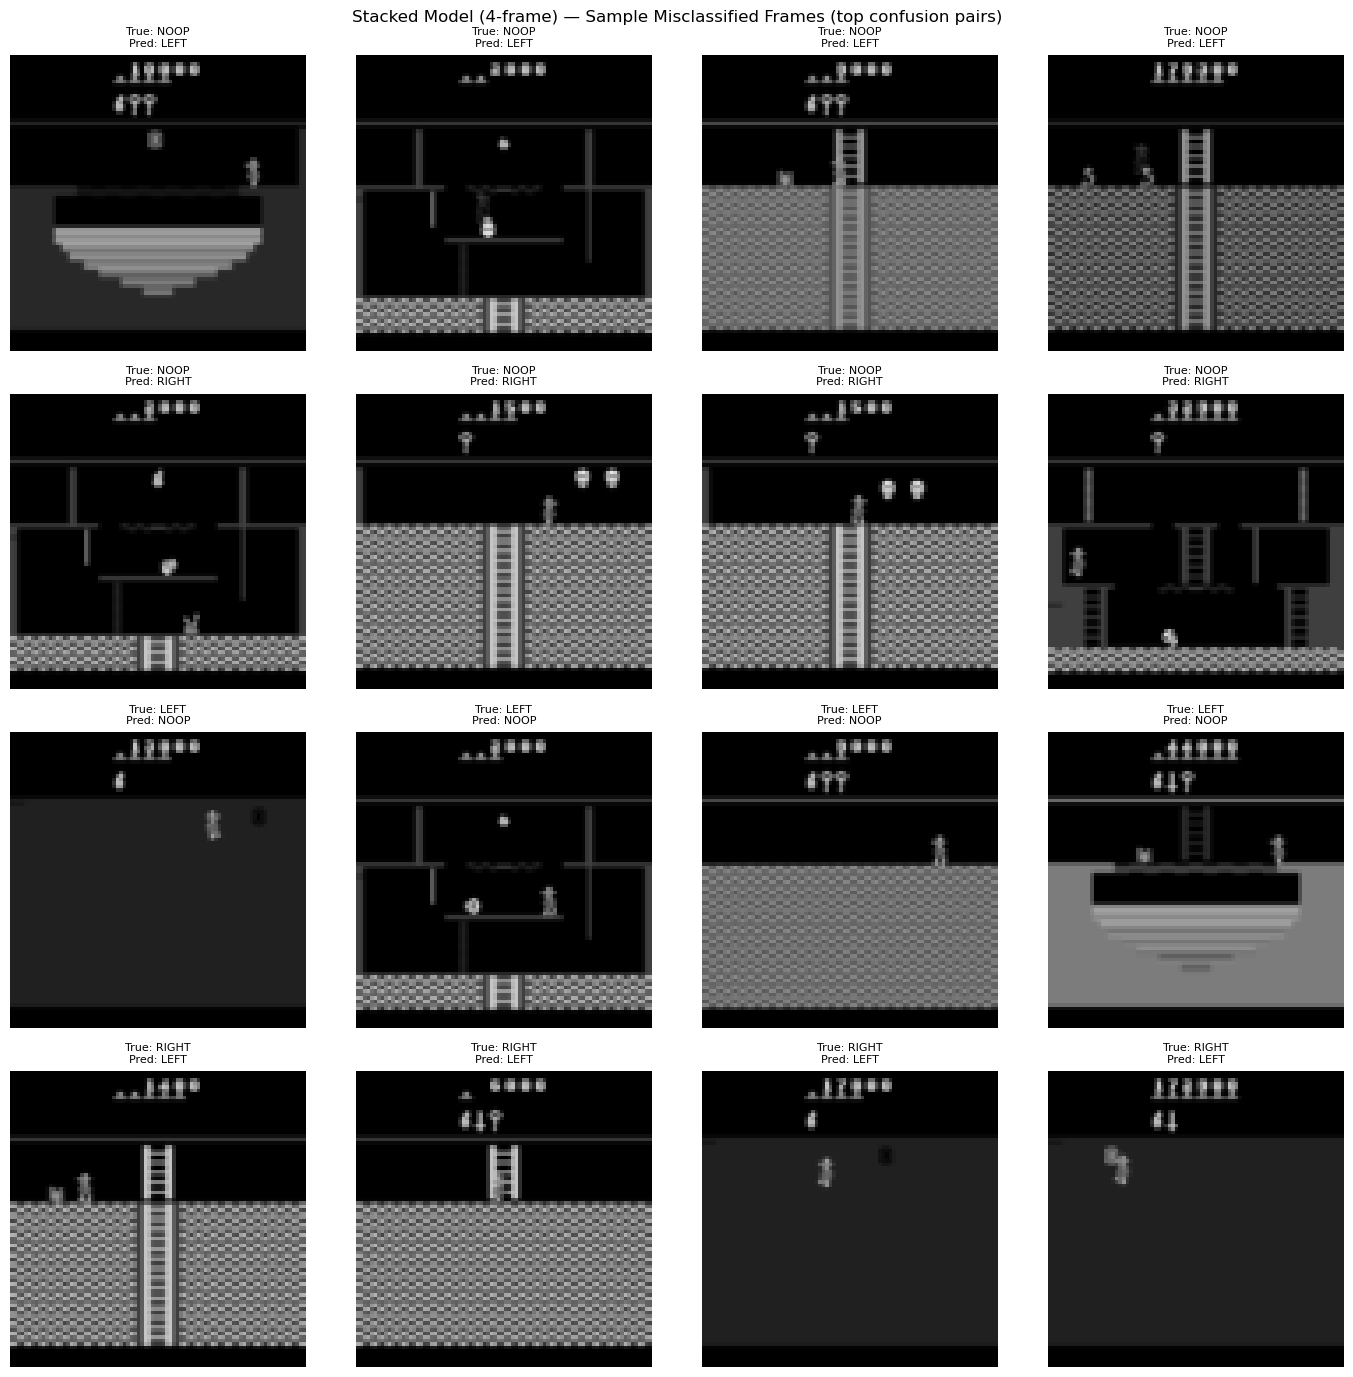

Figure saved to outputs/figures/error_analysis_samples.png


In [27]:
# Visual grid — sample misclassified frames from top 4 confusion pairs
# Each sample index maps into the stacked dataset; we show the last frame
# of the 4-frame stack (the frame being predicted at that timestep).
top_pairs = [pair for pair, _ in pair_counts.most_common(4)]

fig, axes = plt.subplots(len(top_pairs), 4, figsize=(14, 3.5 * len(top_pairs)))

for row, (true_cls, pred_cls) in enumerate(top_pairs):
    pair_mask = (error_true == true_cls) & (error_preds == pred_cls)
    pair_idx  = error_idx[pair_mask]
    chosen    = np.random.default_rng(SEED).choice(pair_idx, size=min(4, len(pair_idx)), replace=False)
    for col in range(4):
        ax = axes[row, col]
        if col < len(chosen):
            # valid_indices[i] gives the start of the 4-frame stack in test_frames;
            # add STACK_SIZE-1 to get the labeled (last) frame of that stack
            frame_pos = int(test_ds_stack.valid_indices[chosen[col]]) + STACK_SIZE - 1
            ax.imshow(test_frames[frame_pos], cmap='gray', vmin=0, vmax=255)
            ax.set_title(f'True: {ACTION_NAMES[true_cls]}\nPred: {ACTION_NAMES[pred_cls]}', fontsize=8)
        ax.axis('off')

fig.suptitle('Stacked Model (4-frame) — Sample Misclassified Frames (top confusion pairs)', fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'error_analysis_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/figures/error_analysis_samples.png')

**Error analysis findings.** The stacked model misclassifies 9.5% of test frames (6,347 of 66,739), a meaningful reduction from the baseline's 13.3% error rate. The confusion patterns are highly structured and reveal what genuinely hard cases remain after temporal context is accounted for.

NOOP is the single largest source of errors: NOOP predicted as LEFT and NOOP predicted as RIGHT are the top two confusion pairs, together accounting for roughly 27.6% of all errors. This is the expected pattern: an idle player standing in a neutral pose near a platform edge produces frames that are visually similar to the early frames of a horizontal movement, and even four consecutive frames of a stationary player can look like the startup phase of directional movement.

RIGHT-LEFT confusion, the dominant error mode in the baseline where LEFT→RIGHT was the single largest confusion pair (1,528 cases), is substantially reduced in the stacked model (LEFT→RIGHT drops to 523 cases). Four consecutive frames encode direction of travel directly, resolving most of the ambiguity that a static snapshot cannot. Cases that remain are likely mid reversal frames where the player stops one direction and begins another within the four frame window.

UP and DOWN errors do not appear among the top confusion pairs, consistent with their strong recall scores (0.94 each). Ladder and rope traversal involves distinctive postures and positions that are visually separable even at 84x84 resolution.

The remaining errors in the stacked model are structurally concentrated in the NOOP vs. action boundary, not the directional distinctions. This supports the case for a hierarchical cascade architecture as a potential next step: separating the idle detection problem from the directional prediction problem would target precisely the confusion pattern that persists at this accuracy level.

## 11. Final Notebook Summary

This project trained and evaluated convolutional neural networks to predict player actions from human Atari Montezuma's Revenge gameplay frames using the Atari-HEAD dataset (Zhang et al., 2020), a collection of 447,300 frames across 27 sessions annotated with real human inputs. The central question was whether providing four consecutive frames of temporal context improves action prediction over a single static frame, using a DQN-inspired CNN architecture held constant across both conditions. The four frame stacked model achieved 90.5% accuracy and 90.4% macro F1 on the held out test set, outperforming the single frame baseline by 3.8 percentage points on accuracy and 3.6 percentage points on macro F1, with the strongest gains on directional classes that require knowing which way the player is moving. A second experiment boosting the NOOP class weight produced genuine improvements (+1.1pp NOOP F1, +1.0pp macro F1), but the stacked model outperformed it by 2.7pp on macro F1, confirming that temporal context is the more effective approach. The primary limitation is that the model represents one player's behavioral signature and may not generalize to players with different skill levels or play styles without retraining on additional subjects.

## References

Goodfellow, I., Bengio, Y., & Courville, A. (2016). Convolutional networks. In *Deep Learning* (chap. 9). MIT Press. https://www.deeplearningbook.org/contents/convnets.html

He, H., & Garcia, E. A. (2009). Learning from imbalanced data. *IEEE Transactions on Knowledge and Data Engineering*, 21(9), 1263–1284. https://doi.org/10.1109/TKDE.2008.239

Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. *Proceedings of the International Conference on Learning Representations (ICLR)*. https://arxiv.org/abs/1412.6980

Mnih, V., Kavukcuoglu, K., Silver, D., Rusu, A. A., Veness, J., Bellemare, M. G., Graves, A., Riedmiller, M., Fidjeland, A. K., Ostrovski, G., Petersen, S., Beattie, C., Sadik, A., Antonoglou, I., King, H., Kumaran, D., Wierstra, D., Legg, S., & Hassabis, D. (2015). Human-level control through deep reinforcement learning. *Nature*, 518(7540), 529–533. https://storage.googleapis.com/deepmind-media/dqn/DQNNaturePaper.pdf

Pomerleau, D. A. (1989). ALVINN: An autonomous land vehicle in a neural network. *Advances in Neural Information Processing Systems*, 1, 305–313. https://proceedings.neurips.cc/paper/1988/file/812b4ba287f5ee0bc9d43bbf5bbe87fb-Paper.pdf

Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. *Journal of Machine Learning Research*, 15(1), 1929–1958. https://jmlr.org/papers/v15/srivastava14a.html

Zhang, R., Walshe, C., Liu, Z., Guan, L., Muller, K., Whritner, J., Zhang, L., Hayhoe, M., & Ballard, D. (2020). Atari-HEAD: Atari human eye-tracking and demonstration dataset. *Proceedings of the AAAI Conference on Artificial Intelligence*, 34(04), 6811–6820. https://doi.org/10.1609/aaai.v34i04.6161